# Dynamic Panel Data Models in Python: From Nickell Bias to System GMM

This notebook is a runnable companion to the blog post [*Dynamic Panel Data Models in Python: From Nickell Bias to System GMM*](https://carlos-mendez.org/post/python_dynamic_panel/).

When this year's outcome depends on last year's outcome — employment, debt, capital, habits — ordinary panel methods break in ways that are invisible on the printed output. Using the classic Arellano and Bond (1991) panel of 140 UK manufacturing firms observed 1976–1984, we estimate the persistence $\rho$ of firm employment with the full estimator ladder: pooled OLS gives 0.962 (biased up), fixed effects gives 0.626 (Nickell bias, down), Anderson-Hsiao IV is consistent but useless (1.233, SE 0.478), and difference GMM hugs the biased bound at 0.679. Blundell-Bond system GMM with 32 collapsed instruments delivers the defensible headline — $\hat{\rho} = 0.927$, clean AR(2) and Hansen diagnostics — and the toolchain replicates the published `pydynpd` benchmark digit for digit.

**Learning objectives:**

- Understand why a lagged dependent variable plus a fixed effect breaks both pooled OLS (bias up) and the within estimator (Nickell bias, down), and how the two wrong answers bracket the truth.
- Implement the full estimator ladder in Python — OLS and fixed effects with `pyfixest`, Anderson-Hsiao IV, and difference and system GMM with `pydynpd`.
- Estimate employment persistence on the classic Arellano-Bond (1991) UK panel and diagnose weak instruments using Bond's (2002) bracket check.
- Assess GMM credibility with the AR(1)/AR(2) serial-correlation tests and the Hansen overidentification test, including the counterintuitive "p close to 1 is a red flag" reading.
- Compare instrument-proliferation choices (lag windows, collapsing) and verify the toolchain against the package's published replication benchmark.

## Setup and imports

We need two workhorse libraries: [`pyfixest`](https://py-econometrics.github.io/pyfixest/pyfixest.html) for the OLS, fixed-effects, and IV benchmarks, and [`pydynpd`](https://github.com/dazhwu/pydynpd) (Wu, Hua and Xu 2023) for difference and system GMM, with a command syntax deliberately close to Stata's `xtabond2`. The version pin matters: the compatibility fix in the next cell targets exactly the 0.2.2 release.

In [1]:
!pip install pydynpd==0.2.2 pyfixest --quiet

One practical wrinkle deserves a friendly explanation rather than a silent workaround. `pydynpd` 0.2.2 was written before NumPy 2.0, which removed the alias `np.in1d` and stopped allowing `float()` and `math.sqrt()` to be called directly on 1x1 matrices. Rather than downgrading NumPy or forking the package, we apply a six-line *compatibility shim*: restore the `np.in1d` alias, and inject tiny wrapper functions into the one `pydynpd` module that does the offending scalar conversions (`specification_tests`). Because Python module globals shadow builtins, the injected `float` and `math.sqrt` wrappers are picked up only inside that module — the rest of the session is untouched. The digit-for-digit replication check near the end of this notebook confirms the shim does not perturb any estimate.

In [2]:
import contextlib
import io
import math
import types
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -- pydynpd 0.2.2 / NumPy 2.x compatibility shim ---------------------
# pydynpd 0.2.2 predates NumPy 2.0, which removed np.in1d and forbids
# float()/math.sqrt() on 1x1 matrices. Module globals shadow builtins,
# so injecting wrappers into pydynpd.specification_tests restores both
# behaviors without forking the package.
if not hasattr(np, "in1d"):
    np.in1d = np.isin
import pydynpd

if getattr(pydynpd, "__version__", "0.2.2") not in ("0.2.2",):
    warnings.warn("Compat shim was written for pydynpd 0.2.2 - "
                  "re-test before trusting results on a newer version")
from pydynpd import specification_tests as _st


def _scalar(v):
    return np.asarray(v).item() if np.ndim(v) else v


_st.float = lambda v: float(_scalar(v))
_st.math = types.SimpleNamespace(sqrt=lambda v: math.sqrt(_scalar(v)))

from pydynpd import regression  # import after shim
import pyfixest as pf

Next, the configuration block: the random seed (used only to pick which firms appear in Figure 1 — every estimator below is closed-form and deterministic), the site color palette, the dark-theme matplotlib settings, and two strings that define our *running specification*. `SPEC_MAIN` is the pydynpd formula for the AR(1) labor-demand model — `n` on its first lag plus current and lagged `w` and `k` — and `GMM_FULL` declares that all lags from $t-2$ back to the start of the sample (`2:99`) of `n`, `w`, and `k` are available as GMM-style instruments.

In [3]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Site color palette
STEEL_BLUE = "#6a9bcc"
WARM_ORANGE = "#d97757"
NEAR_BLACK = "#141413"
TEAL = "#00d4c8"
GRAY = "#999999"

# Dark theme palette
DARK_NAVY = "#0f1729"
GRID_LINE = "#1f2b5e"
LIGHT_TEXT = "#c8d0e0"
WHITE_TEXT = "#e8ecf2"

plt.rcParams.update({
    "figure.facecolor": DARK_NAVY,
    "axes.facecolor": DARK_NAVY,
    "axes.edgecolor": DARK_NAVY,
    "axes.linewidth": 0,
    "axes.labelcolor": LIGHT_TEXT,
    "axes.titlecolor": WHITE_TEXT,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.spines.bottom": False,
    "axes.grid": True,
    "grid.color": GRID_LINE,
    "grid.linewidth": 0.6,
    "grid.alpha": 0.8,
    "xtick.color": LIGHT_TEXT,
    "ytick.color": LIGHT_TEXT,
    "xtick.major.size": 0,
    "ytick.major.size": 0,
    "text.color": WHITE_TEXT,
    "font.size": 12,
    "legend.frameon": False,
    "legend.fontsize": 11,
    "legend.labelcolor": LIGHT_TEXT,
    "figure.edgecolor": DARK_NAVY,
    "savefig.facecolor": DARK_NAVY,
    "savefig.edgecolor": DARK_NAVY,
})

VAR_LABELS = {
    "n": "Log employment",
    "w": "Log real wage",
    "k": "Log capital stock",
    "ys": "Log industry output",
}

SPEC_MAIN = "n L(1:1).n L(0:1).w L(0:1).k"
GMM_FULL = "gmm(n, 2:99) gmm(w, 2:99) gmm(k, 2:99)"

Finally, two small helpers we will reuse constantly. `run_abond` wraps `pydynpd.regression.abond` — the package's single entry point, which takes a Stata-style command string, the dataframe, and the panel identifiers `["id", "year"]` — and optionally swallows the table it prints (useful in the proliferation grid, where we run six models and want a readable log). `gmm_summary` pulls the headline numbers out of a fitted model: $\hat{\rho}$ and its standard error, a 95 percent confidence interval, the Hansen and AR-test p-values, and the instrument count.

In [4]:
def run_abond(command_str, df, quiet=False):
    """Run pydynpd and return the first fitted model.

    pydynpd prints its regression table to stdout as a side effect; quiet=True
    suppresses that (used in the proliferation grid to keep the log readable).
    """
    if quiet:
        with contextlib.redirect_stdout(io.StringIO()):
            return regression.abond(command_str, df, ["id", "year"]).models[0]
    return regression.abond(command_str, df, ["id", "year"]).models[0]


def gmm_summary(model, label):
    """Extract headline numbers from a fitted pydynpd model."""
    rt = model.regression_table
    rho = rt.loc[rt.variable == "L1.n", "coefficient"].iloc[0]
    se = rt.loc[rt.variable == "L1.n", "std_err"].iloc[0]
    return {
        "estimator": label,
        "rho1": rho,
        "se": se,
        "ci_lo": rho - 1.96 * se,
        "ci_hi": rho + 1.96 * se,
        "hansen_p": model.hansen.p_value,
        "ar1_p": model.AR_list[0].P_value,
        "ar2_p": model.AR_list[1].P_value,
        "n_instruments": model.z_information.num_instr,
    }

## Data loading and panel structure

The dataset is the original Arellano and Bond (1991) panel: an unbalanced sample of UK manufacturing firms observed annually from 1976 to 1984 — the canonical teaching dataset of this literature, so every number we produce can be checked against forty years of published output. The columns we use are already in logs: `n` (employment), `w` (real wage), `k` (gross capital), and `ys` (industry output). We load it from the blog's GitHub repository, falling back to a local copy if the notebook runs next to the post bundle.

Before estimating anything, we want three facts: how big the panel is, how unbalanced it is, and — most importantly — *where the variation lives* (between firms or within firms over time).

In [5]:
URL = "https://raw.githubusercontent.com/cmg777/starter-academic-v501/master/content/post/python_dynamic_panel/abdata.csv"
try:
    df = pd.read_csv(URL)
except Exception:
    df = pd.read_csv("abdata.csv")  # local fallback (post bundle)

print(f"Dataset shape: {df.shape}")
print(f"Firms: {df['id'].nunique()}, years: {df['year'].min()}-{df['year'].max()}")

obs_per_firm = df.groupby("id").size()
print("\nObservations per firm (unbalanced panel):")
print(obs_per_firm.value_counts().sort_index().rename_axis("years_observed")
      .to_frame("n_firms").to_string())

print("\nSummary statistics (log variables used in estimation):")
print(df[["n", "w", "k", "ys"]].describe().round(3).to_string())

firm_mean_n = df.groupby("id")["n"].transform("mean")
print(f"\nBetween-firm SD of log employment: {df.groupby('id')['n'].mean().std():.3f}")
print(f"Within-firm SD of log employment:  {(df['n'] - firm_mean_n).std():.3f}")

Dataset shape: (1031, 10)
Firms: 140, years: 1976-1984

Observations per firm (unbalanced panel):
                n_firms
years_observed         
7                   103
8                    23
9                    14

Summary statistics (log variables used in estimation):
              n         w         k        ys
count  1031.000  1031.000  1031.000  1031.000
mean      1.056     3.143    -0.442     4.638
std       1.342     0.263     1.514     0.094
min      -2.263     2.082    -4.431     4.465
25%       0.166     3.027    -1.510     4.576
50%       0.827     3.178    -0.658     4.611
75%       1.949     3.314     0.406     4.706
max       4.687     3.812     3.852     4.855

Between-firm SD of log employment: 1.339
Within-firm SD of log employment:  0.195


**Interpretation.** The panel holds 1,031 firm-year observations on 140 firms — *short and wide*: many firms (large N) observed for only 7 to 9 years each (small T). That geometry is exactly the setting dynamic-panel GMM was designed for, and exactly where Nickell bias — which shrinks at rate $1/T$ — bites hardest. The decisive number is the variance decomposition: the between-firm SD of log employment (1.339) is nearly **seven times** the within-firm SD (0.195). Employment differences live almost entirely *across* firms, so the unobserved firm level $\alpha_i$ is the dominant feature of these data — and any estimator that mishandles it will be wrong by a lot, not a little.

A picture makes the same point more vividly: 40 randomly chosen firms (the only place the seed is used), the median across all 140 firms, and one example firm.

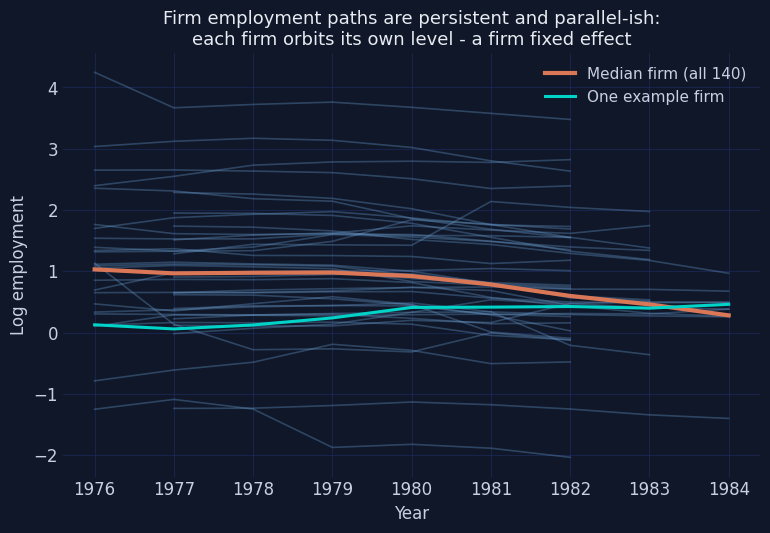

In [6]:
rng = np.random.default_rng(RANDOM_SEED)
sample_ids = rng.choice(df["id"].unique(), size=40, replace=False)

fig, ax = plt.subplots(figsize=(9, 5.5))
fig.patch.set_linewidth(0)
for fid in sample_ids:
    firm = df[df["id"] == fid].sort_values("year")
    ax.plot(firm["year"], firm["n"], color=STEEL_BLUE, alpha=0.35, lw=1.2)
median_path = df.groupby("year")["n"].median()
ax.plot(median_path.index, median_path.values, color=WARM_ORANGE, lw=3,
        label="Median firm (all 140)")
big = df[df["id"] == obs_per_firm.idxmax()].sort_values("year")
ax.plot(big["year"], big["n"], color=TEAL, lw=2.2, label="One example firm")
ax.set_xlabel("Year")
ax.set_ylabel(VAR_LABELS["n"])
ax.set_title("Firm employment paths are persistent and parallel-ish:\n"
             "each firm orbits its own level - a firm fixed effect",
             fontsize=13)
ax.legend(loc="upper right")
plt.show()

**Interpretation.** Each blue line is one firm, and the picture shows the two ingredients that make $\rho$ hard to estimate, simultaneously. First, the lines are roughly *parallel* and rarely cross: each firm orbits its own level — the visual signature of a large firm fixed effect $\alpha_i$. Second, each line is *smooth*: employment this year looks a lot like last year — the visual signature of high persistence. The orange median drifts gently downward after 1980 (the early-1980s UK manufacturing recession, a common shock the year dummies will absorb). An estimator that ignores $\alpha_i$ will mistake orbit differences for persistence; one that removes $\alpha_i$ clumsily will damage the persistence signal it is trying to measure.

## Data preparation: lags and first differences

Every estimator below runs on transformed variables: one-period lags of `n`, `w`, and `k` for the level equations, and first differences for the Anderson-Hsiao regression. Two details matter. The transformations must respect firm boundaries — which is why everything goes through `groupby("id")` — and each lag is *expensive*: it costs every firm its first observed year.

In [7]:
d = df.sort_values(["id", "year"]).copy()
g = d.groupby("id")
for v in ["n", "w", "k"]:
    d[f"{v}_lag1"] = g[v].shift(1)
d["n_lag2"] = g["n"].shift(2)
for v in ["n", "w", "k"]:
    d[f"d_{v}"] = g[v].diff()
d["d_n_lag1"] = g["d_n"].shift(1)
d["d_w_lag1"] = g["d_w"].shift(1)
d["d_k_lag1"] = g["d_k"].shift(1)

est_sample = d.dropna(subset=["n_lag1", "w_lag1", "k_lag1"]).copy()
print(f"Full panel rows: {len(d)}")
print(f"Estimation sample after requiring one lag: {len(est_sample)} rows "
      f"({est_sample['id'].nunique()} firms)")

Full panel rows: 1031
Estimation sample after requiring one lag: 891 rows (140 firms)


**Interpretation.** Requiring a single lag shrinks the sample from 1,031 to 891 rows — a 13.6 percent cut — while keeping all 140 firms. This is the first lesson in dynamic-panel frugality: with T as small as 7, every additional lag or difference burns a meaningful share of the data. Watch the observation counts fall as the methods get hungrier — the GMM estimators below run on 751 observations, and the two-lag replication specification at the end on just 611.

## The bias bracket: pooled OLS vs fixed effects

We now run the *same regression* twice — log employment on its lag, wages, capital, and year dummies — changing only how it treats the firm effect $\alpha_i$. Both treatments fail, but in *opposite, theoretically known directions*, and that is what makes the failure useful.

**Why pooled OLS is biased upward.** Pooled OLS ignores $\alpha_i$, leaving it in the error term. But last year's employment $n_{i,t-1}$ depends on $\alpha_i$ — high-level firms had high employment last year too — so the regressor is positively correlated with the error. Persistently large firms look like firms with enormous persistence, and $\hat{\rho}$ gets pushed *up* toward 1.

**Why fixed effects is biased downward.** The within estimator subtracts each firm's sample average, which removes $\alpha_i$ exactly — but that average contains the firm's *future* shocks, creating a mechanical *negative* correlation between the demeaned lag and the demeaned error: the Nickell (1981) bias, of order $1/T$. With T of 7–9 it is large, and adding more firms does not help.

Two failures with known signs are a measurement instrument in their own right: Bond (2002) turned them into a diagnostic *bracket* that any consistent estimator must land inside. In the `pf.feols` calls, `| year` absorbs year fixed effects (`| id + year` absorbs both), and `vcov={"CRV1": "id"}` requests cluster-robust standard errors by firm.

In [8]:
FORMULA_RHS = "n_lag1 + w + w_lag1 + k + k_lag1"
ols = pf.feols(f"n ~ {FORMULA_RHS} | year", data=est_sample,
               vcov={"CRV1": "id"})
fe = pf.feols(f"n ~ {FORMULA_RHS} | id + year", data=est_sample,
              vcov={"CRV1": "id"})

print("Pooled OLS (year dummies, SEs clustered by firm):")
print(ols.tidy().round(4).to_string())
print("\nFixed effects / within (firm + year dummies, clustered SEs):")
print(fe.tidy().round(4).to_string())

rho_ols, se_ols = ols.coef()["n_lag1"], ols.se()["n_lag1"]
rho_fe, se_fe = fe.coef()["n_lag1"], fe.se()["n_lag1"]
print(f"\n  rho_OLS = {rho_ols:.4f} (se {se_ols:.4f})   <- upper bound (biased up)")
print(f"  rho_FE  = {rho_fe:.4f} (se {se_fe:.4f})   <- lower bound (biased down)")

Pooled OLS (year dummies, SEs clustered by firm):
             Estimate  Std. Error   t value  Pr(>|t|)    2.5%   97.5%
Coefficient                                                          
n_lag1         0.9617      0.0084  115.0717    0.0000  0.9452  0.9782
w             -0.4147      0.1600   -2.5915    0.0106 -0.7311 -0.0983
w_lag1         0.3556      0.1559    2.2803    0.0241  0.0473  0.6639
k              0.3997      0.0565    7.0710    0.0000  0.2879  0.5114
k_lag1        -0.3675      0.0565   -6.4990    0.0000 -0.4793 -0.2557

Fixed effects / within (firm + year dummies, clustered SEs):
             Estimate  Std. Error  t value  Pr(>|t|)    2.5%   97.5%
Coefficient                                                         
n_lag1         0.6262      0.0515  12.1510    0.0000  0.5243  0.7281
w             -0.5035      0.1450  -3.4729    0.0007 -0.7902 -0.2169
w_lag1         0.2308      0.1077   2.1420    0.0339  0.0178  0.4438
k              0.4078      0.0566   7.2024    0.0000 

**Interpretation.** The two "wrong" estimators disagree by 0.336 — an enormous gap in economic terms. Pooled OLS says $\hat{\rho} = 0.9617$, so close to a unit root that an employment shock would have a half-life of about 18 years; fixed effects says $\hat{\rho} = 0.6262$, a half-life of about 1.5 years. Same data, same regression, opposite stories — and *neither is right*, but both errors have known sign. The bracket [0.626, 0.962] is sharply identified: the two cluster-robust confidence intervals do not even overlap. The bracket deserves its own picture, because it is the yardstick every later estimate will be measured against.

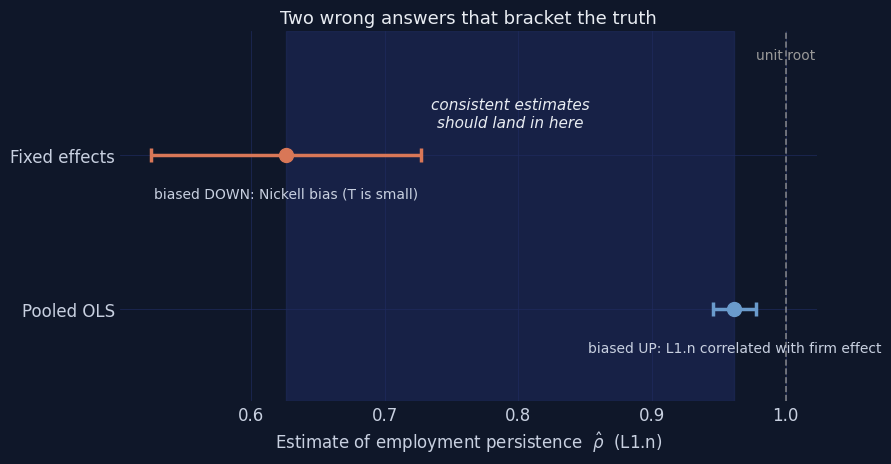

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.8))
fig.patch.set_linewidth(0)
ax.axvspan(rho_fe, rho_ols, color=GRID_LINE, alpha=0.55, zorder=0)
ax.axvline(1.0, color=GRAY, lw=1.2, ls="--", alpha=0.8)
ax.text(1.0, 1.62, "unit root", color=GRAY, fontsize=10, ha="center")
for y, (lab, rho, se, col, note) in enumerate([
    ("Pooled OLS", rho_ols, se_ols, STEEL_BLUE,
     "biased UP: L1.n correlated with firm effect"),
    ("Fixed effects", rho_fe, se_fe, WARM_ORANGE,
     "biased DOWN: Nickell bias (T is small)"),
]):
    ax.errorbar(rho, y, xerr=1.96 * se, fmt="o", color=col, ms=10,
                capsize=5, lw=2.5, capthick=2.5)
    ax.text(rho, y - 0.28, note, color=LIGHT_TEXT, fontsize=10, ha="center")
ax.text((rho_fe + rho_ols) / 2, 1.18,
        "consistent estimates\nshould land in here", color=WHITE_TEXT,
        fontsize=11, ha="center", style="italic")
ax.set_yticks([0, 1])
ax.set_yticklabels(["Pooled OLS", "Fixed effects"])
ax.set_ylim(-0.6, 1.8)
ax.set_xlabel(r"Estimate of employment persistence  $\hat{\rho}$  (L1.n)")
ax.set_title("Two wrong answers that bracket the truth", fontsize=13)
plt.show()

**Interpretation.** The shaded band between 0.626 and 0.962 is the playing field for the rest of the notebook. Bond's (2002) rule: a candidate estimator landing *below* the band is suffering something Nickell-like; one landing *above* it is suffering something OLS-like or worse; and one landing just barely inside the band, hugging an edge, is probably being dragged toward that edge by a fixable weakness. With the yardstick built, we can try the first estimator that is actually *consistent* for $\rho$.

## Anderson-Hsiao IV: consistent but imprecise

Anderson and Hsiao (1981) proposed a two-step escape. **Step one: difference away the firm effect.** First-differencing eliminates $\alpha_i$ exactly — but it makes the differenced lag $\Delta n_{i,t-1}$ endogenous, because it contains $\varepsilon_{i,t-1}$, which also lives inside $\Delta\varepsilon_{it}$. **Step two: instrument the differenced lag** with the *level* $n_{i,t-2}$: it helps predict the change $\Delta n_{i,t-1}$, and — provided $\varepsilon_{it}$ is not serially correlated — it predates and is therefore independent of both shocks inside $\Delta\varepsilon_{it}$. We estimate by 2SLS, which `pyfixest` expresses with a third formula part: `d_n_lag1 ~ n_lag2`.

In [10]:
ah_sample = d.dropna(subset=["d_n", "d_n_lag1", "d_w", "d_w_lag1",
                             "d_k", "d_k_lag1", "n_lag2"]).copy()
ah = pf.feols("d_n ~ d_w + d_w_lag1 + d_k + d_k_lag1 | year | d_n_lag1 ~ n_lag2",
              data=ah_sample, vcov={"CRV1": "id"})
print("Anderson-Hsiao 2SLS (differences, year dummies, clustered SEs):")
print(ah.tidy().round(4).to_string())

rho_ah, se_ah = ah.coef()["d_n_lag1"], ah.se()["d_n_lag1"]
print(f"\n  rho_AH = {rho_ah:.4f} (se {se_ah:.4f})")
print(f"  95% CI: [{rho_ah - 1.96 * se_ah:.3f}, {rho_ah + 1.96 * se_ah:.3f}]")

Anderson-Hsiao 2SLS (differences, year dummies, clustered SEs):
             Estimate  Std. Error  t value  Pr(>|t|)    2.5%   97.5%
Coefficient                                                         
d_w           -0.5243      0.2135  -2.4556    0.0153 -0.9465 -0.1021
d_w_lag1       0.5808      0.3128   1.8566    0.0655 -0.0377  1.1992
d_k            0.2463      0.0777   3.1693    0.0019  0.0927  0.4000
d_k_lag1      -0.2925      0.1964  -1.4890    0.1388 -0.6808  0.0959
d_n_lag1       1.2327      0.4782   2.5781    0.0110  0.2873  2.1781

  rho_AH = 1.2327 (se 0.4782)
  95% CI: [0.296, 2.170]


**Interpretation.** The point estimate is $\hat{\rho} = 1.2327$ — *above* the unit root, outside the bracket — with a standard error of 0.4782, nearly 60 times the OLS standard error. The 95 percent confidence interval [0.296, 2.170] contains the entire OLS-FE bracket, the unit root, and explosive dynamics, all at once. Taken correctly, it says one instrument extracts far too little information from a highly persistent series to be useful. The fix is not a *better* witness but *more* of them: if $n_{i,t-2}$ is a valid instrument, then by the same logic so are $n_{i,t-3}$, $n_{i,t-4}$, and every deeper lag — the doorway to GMM.

## Difference GMM (Arellano-Bond 1991)

Arellano and Bond turn Anderson-Hsiao's single moment condition into a whole family. Under sequential exogeneity and no serial correlation in $\varepsilon_{it}$, *every* level dated $t-2$ or earlier is uncorrelated with the differenced error:

$$E[n_{i,t-s} \Delta\varepsilon_{it}] = 0 \quad \text{for all } s \ge 2$$

The same holds for lagged `w` and `k`, and GMM combines the dozens of resulting conditions optimally. The `pydynpd` command string encodes exactly this: `SPEC_MAIN` plus `gmm(n, 2:99) gmm(w, 2:99) gmm(k, 2:99)` (use every lag from depth 2 onward), `timedumm` (year dummies), and `nolevel` (differenced equation only — that is what makes it *difference* GMM). GMM comes in *one-step* and *two-step* flavors; two-step is asymptotically more efficient, and `pydynpd` reports the Windmeijer (2005) finite-sample correction for its standard errors, so the two-step column is the one to quote.

In [11]:
print("One-step difference GMM:")
diff_one = run_abond(f"{SPEC_MAIN} | {GMM_FULL} | timedumm nolevel onestep", d)
print("\nTwo-step difference GMM (Windmeijer-corrected SEs):")
diff_two = run_abond(f"{SPEC_MAIN} | {GMM_FULL} | timedumm nolevel", d)

s1 = gmm_summary(diff_one, "Diff GMM (one-step)")
s2 = gmm_summary(diff_two, "Diff GMM (two-step)")
print(f"\n  one-step: rho = {s1['rho1']:.4f} (se {s1['se']:.4f})")
print(f"  two-step: rho = {s2['rho1']:.4f} (se {s2['se']:.4f}), "
      f"{s2['n_instruments']} instruments")

One-step difference GMM:
 Dynamic panel-data estimation, one-step difference GMM
 Group variable: id                               Number of obs = 751     
 Time variable: year                              Min obs per group: 5    
 Number of instruments = 91                       Max obs per group: 7    
 Number of groups = 140                           Avg obs per group: 5.36 
+-----------+------------+---------------------+------------+-----------+-----+
|     n     |   coef.    | Corrected Std. Err. |     z      |   P>|z|   |     |
+-----------+------------+---------------------+------------+-----------+-----+
|    L1.n   | 0.7074701  |      0.0841788      | 8.4043723  | 0.0000000 | *** |
|     w     | -0.7087965 |      0.1171020      | -6.0528147 | 0.0000000 | *** |
|    L1.w   | 0.5000149  |      0.1113282      | 4.4913603  | 0.0000071 | *** |
|     k     | 0.4659776  |      0.1010440      | 4.6116293  | 0.0000040 | *** |
|    L1.k   | -0.2151309 |      0.0858525      | -2.5058195

**Interpretation.** The machinery works exactly as advertised — 91 instruments across 751 usable observations, a two-step estimate of $\hat{\rho} = 0.6788$ (SE 0.0891), and every printed diagnostic passes: AR(1) rejects as it mechanically must, AR(2) is nowhere near rejecting (p = 0.866), and Hansen accepts (p = 0.211). And yet this estimate should *not* be trusted, for a reason no printed test reveals: it sits only 0.053 above the FE lower bound of 0.626 — within one standard error of it, in the bottom sixth of the bracket. This is Bond's (2002) informal diagnostic failing loudly. When the true series is highly persistent, the level two years ago barely predicts this year's *change* — so all 91 instruments are individually weak, and weak-instrument bias in this design points toward the within estimator. Blundell and Bond (1998) demonstrated precisely this failure *on precisely this dataset* — and their fix is next.

## System GMM (Blundell-Bond 1998): the headline model

If lagged *levels* are weak instruments for *differences*, what about the reverse? Lagged *differences* turn out to be strong instruments for *levels*. System GMM estimates a stacked *system* of both equations at once: the differenced equation keeps its Arellano-Bond instruments, and the levels equation gets instrumented by lagged differences via the new moment conditions

$$E[\Delta n_{i,t-1}(\alpha_i + \varepsilon_{it})] = 0$$

That is a genuinely new assumption — *mean stationarity*: firms may sit at wildly different steady-state levels, but their initial deviations from those steady states must be unrelated to the levels themselves. Two practical choices complete the headline specification: *collapsed* instruments (`collapse` combines each lag depth into a single instrument column, holding the count to 32, safely below Roodman's rule that instruments should not outnumber the 140 firms), and two-step Windmeijer-corrected results. Dropping `nolevel` from the command string is what switches `pydynpd` from difference to system GMM.

In [12]:
print("Two-step system GMM, collapsed instruments:")
sys_two = run_abond(f"{SPEC_MAIN} | {GMM_FULL} | timedumm collapse", d)
print("\nOne-step system GMM, collapsed instruments:")
sys_one = run_abond(f"{SPEC_MAIN} | {GMM_FULL} | timedumm collapse onestep", d)

s3 = gmm_summary(sys_two, "Sys GMM (two-step, collapsed)")
s4 = gmm_summary(sys_one, "Sys GMM (one-step, collapsed)")
print(f"\n  two-step: rho = {s3['rho1']:.4f} (se {s3['se']:.4f}), "
      f"{s3['n_instruments']} instruments")
print(f"  one-step: rho = {s4['rho1']:.4f} (se {s4['se']:.4f})")

Two-step system GMM, collapsed instruments:
 Dynamic panel-data estimation, two-step system GMM
 Group variable: id                               Number of obs = 751     
 Time variable: year                              Min obs per group: 5    
 Number of instruments = 32                       Max obs per group: 7    
 Number of groups = 140                           Avg obs per group: 5.36 
+-----------+------------+---------------------+------------+-----------+-----+
|     n     |   coef.    | Corrected Std. Err. |     z      |   P>|z|   |     |
+-----------+------------+---------------------+------------+-----------+-----+
|    L1.n   | 0.9269913  |      0.0785085      | 11.8075341 | 0.0000000 | *** |
|     w     | -0.8155041 |      0.2763832      | -2.9506278 | 0.0031713 |  ** |
|    L1.w   | 0.6331152  |      0.3327639      | 1.9025958  | 0.0570933 |     |
|     k     | 0.5894690  |      0.1715356      | 3.4364236  | 0.0005894 | *** |
|    L1.k   | -0.4888581 |      0.1969821   

**Interpretation.** This is the headline: $\hat{\rho} = 0.9270$ (SE 0.0785) — inside the bracket, in its upper half, 0.25 above the weak-instrument difference-GMM estimate, with 32 collapsed instruments and textbook diagnostics. Substantively, about 93 percent of an employment shock survives into the next year — a shock half-life of roughly nine years — versus the 1.5 years fixed effects would have claimed. One honest caveat: the 95 percent CI [0.773, 1.081] includes 1.0, so a unit root cannot be rejected; the defensible claim is the point estimate and its lower bound.

**Reading the diagnostics** (each has a non-obvious reading):

| Test | Correct reading | Our headline value |
|---|---|---|
| AR(1) in differences | **Must reject.** Differencing makes adjacent errors share $\varepsilon_{i,t-1}$, so rejection is mechanical and *good news* | z = -4.49, p = 0.000 — rejects, as required |
| AR(2) in differences | **Must not reject.** This is the test that validates the $t-2$ instruments: serial correlation in $\varepsilon_{it}$ would contaminate them | z = -0.01, p = 0.994 — clean |
| Hansen J | **Two-tailed in spirit.** p < 0.05 means instruments look invalid; p near 1 means the test has been overwhelmed by too many instruments | p = 0.462 — comfortable on both sides |

That last claim — that the Hansen p-value responds to the instrument *count*, not just instrument *validity* — is testable on our own data. Let us run the experiment.

## Instrument proliferation: lag windows vs collapse

We re-estimate the *identical* system-GMM model six times, varying only two plumbing choices: the lag window (`2:3` = use lags 2 and 3 only; `2:5`; `2:99` = use everything) and whether the instrument matrix is collapsed. If the Hansen test were a pure validity meter, its p-value would be roughly stable across these cells. It is not.

In [13]:
grid_specs = [
    ("2:3", False), ("2:3", True),
    ("2:5", False), ("2:5", True),
    ("2:99", False), ("2:99", True),
]
grid_rows = []
for window, collapsed in grid_specs:
    gmm_part = f"gmm(n, {window}) gmm(w, {window}) gmm(k, {window})"
    opts = "timedumm collapse" if collapsed else "timedumm"
    model = run_abond(f"{SPEC_MAIN} | {gmm_part} | {opts}", d, quiet=True)
    row = gmm_summary(model, f"sys GMM lags {window}"
                      + (", collapsed" if collapsed else ""))
    row["lag_window"] = window
    row["collapsed"] = collapsed
    grid_rows.append(row)
    print(f"  lags {window:5s} collapse={str(collapsed):5s} -> "
          f"{row['n_instruments']:3d} instruments, rho = {row['rho1']:.3f}, "
          f"Hansen p = {row['hansen_p']:.3f}")

grid = pd.DataFrame(grid_rows)

  lags 2:3   collapse=False ->  68 instruments, rho = 0.956, Hansen p = 0.035


  lags 2:3   collapse=True  ->  17 instruments, rho = 0.921, Hansen p = 0.096
  lags 2:5   collapse=False ->  95 instruments, rho = 0.935, Hansen p = 0.186


  lags 2:5   collapse=True  ->  23 instruments, rho = 0.937, Hansen p = 0.255
  lags 2:99  collapse=False -> 113 instruments, rho = 0.930, Hansen p = 0.235
  lags 2:99  collapse=True  ->  32 instruments, rho = 0.927, Hansen p = 0.462


**Interpretation.** Two findings, both reassuring and unsettling at once. The reassuring one: $\hat{\rho}$ barely moves — all six cells land in the narrow range [0.921, 0.956], so the *point estimate* is robust to the plumbing. The unsettling one: the *test we would use to defend it* is not. Reading the uncollapsed rows top to bottom, the instrument count climbs 68, 95, 113 (approaching the 140-firm ceiling) and the Hansen p-value drifts 0.035, 0.186, 0.235 — even though the model never changes. That upward drift is the overfitting trajectory whose endpoint is the notorious "p = 1.000" red flag. The grid also catches proliferation distorting the test in the *other* tail: the uncollapsed 2:3 specification is outright *rejected* by Hansen (p = 0.035) while its collapsed twin passes (p = 0.096) — same lag window, same data, opposite verdicts, driven purely by instrument count.

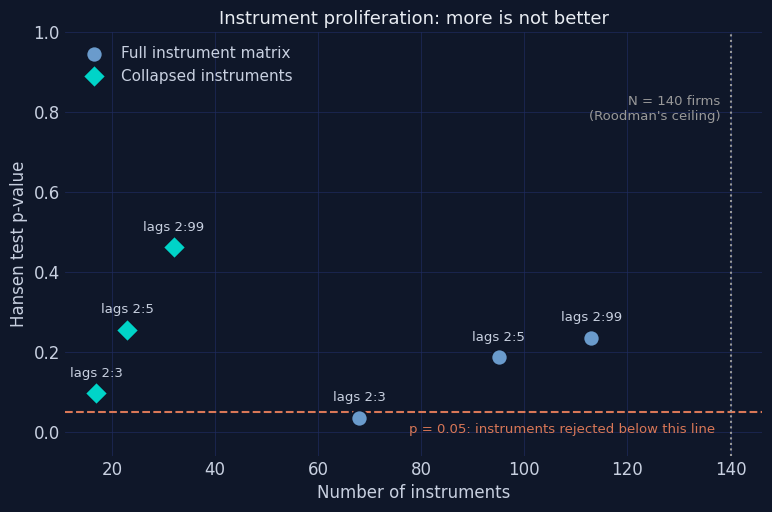

In [14]:
fig, ax = plt.subplots(figsize=(9, 5.5))
fig.patch.set_linewidth(0)
for collapsed, col, marker, lab in [(False, STEEL_BLUE, "o", "Full instrument matrix"),
                                    (True, TEAL, "D", "Collapsed instruments")]:
    sub = grid[grid["collapsed"] == collapsed]
    ax.scatter(sub["n_instruments"], sub["hansen_p"], s=140, color=col,
               marker=marker, edgecolors=DARK_NAVY, lw=1.5, zorder=3, label=lab)
    for _, r in sub.iterrows():
        ax.annotate(f"lags {r['lag_window']}",
                    (r["n_instruments"], r["hansen_p"]),
                    textcoords="offset points", xytext=(0, 12),
                    color=LIGHT_TEXT, fontsize=9.5, ha="center")
ax.axhline(0.05, color=WARM_ORANGE, lw=1.5, ls="--")
ax.text(137, 0.022, "p = 0.05: instruments rejected below this line",
        color=WARM_ORANGE, fontsize=9.5, ha="right", va="top")
ax.axvline(140, color=GRAY, lw=1.5, ls=":")
ax.text(138, 0.78, "N = 140 firms\n(Roodman's ceiling)", color=GRAY,
        fontsize=9.5, ha="right")
ax.set_xlabel("Number of instruments")
ax.set_ylabel("Hansen test p-value")
ax.set_ylim(-0.06, 1.0)
ax.set_title("Instrument proliferation: more is not better", fontsize=13)
ax.legend(loc="upper left")
plt.show()

**Interpretation.** The teal diamonds (collapsed) buy nearly identical point estimates with a quarter of the instruments, at the honest price of larger standard errors — 0.0785 collapsed versus 0.0274 uncollapsed at the 2:99 window. That uncollapsed SE looks like a precision triumph, but it is precisely the too-good-to-be-true precision Roodman warns about: 113 instruments fitted to 140 firms are partly fitting noise, and the same overfitting that flatters the SE is what disarms the Hansen test. Our headline deliberately takes the larger, more honest standard error.

## Replication check: the pydynpd documentation example

Good practice with any estimation package — especially one we patched with a compatibility shim — is to replicate its published benchmark before trusting novel output. The `pydynpd` README estimates the *original* Arellano-Bond (1991) two-lag specification on this same dataset: two lags of `n`, a restricted instrument window `gmm(n, 2:4)`, wages treated as predetermined with `gmm(w, 1:3)`, capital as a standard exogenous instrument `iv(k)`, and difference GMM (`nolevel`). The package authors validated that output against Stata's `xtabond2`. Note this is a *different model* from our running specification — the point here is toolchain verification, not a second opinion on $\rho$. The hard assertion below aborts the run on any discrepancy.

In [15]:
ab_repl = run_abond(
    "n L(1:2).n w k | gmm(n, 2:4) gmm(w, 1:3) iv(k) | timedumm nolevel", d)
rt = ab_repl.regression_table
rho_repl = rt.loc[rt.variable == "L1.n", "coefficient"].iloc[0]
print(f"\n  Published vignette values: L1.n = 0.2710675, Hansen chi2 = 32.666,")
print("  42 instruments.")
print(f"  Our run:                   L1.n = {rho_repl:.7f}, Hansen chi2 = "
      f"{ab_repl.hansen.test_value:.3f}, {ab_repl.z_information.num_instr} instruments.")
match = (abs(rho_repl - 0.2710675) < 1e-6
         and abs(ab_repl.hansen.test_value - 32.666) < 1e-3
         and ab_repl.z_information.num_instr == 42)
print(f"  Exact match: {match}")
if not match:
    raise AssertionError("Replication check failed - investigate before publishing")

 Dynamic panel-data estimation, two-step difference GMM
 Group variable: id                               Number of obs = 611     
 Time variable: year                              Min obs per group: 4    
 Number of instruments = 42                       Max obs per group: 6    
 Number of groups = 140                           Avg obs per group: 4.36 
+-----------+------------+---------------------+------------+-----------+-----+
|     n     |   coef.    | Corrected Std. Err. |     z      |   P>|z|   |     |
+-----------+------------+---------------------+------------+-----------+-----+
|    L1.n   | 0.2710675  |      0.1382542      | 1.9606462  | 0.0499203 |  *  |
|    L2.n   | -0.0233928 |      0.0419665      | -0.5574151 | 0.5772439 |     |
|     w     | -0.5668527 |      0.2092231      | -2.7093219 | 0.0067421 |  ** |
|     k     | 0.3613939  |      0.0662624      | 5.4539824  | 0.0000000 | *** |
| year_1979 | 0.0011898  |      0.0092322      | 0.1288765  | 0.8974554 |     |
| ye

**Interpretation.** The replication is exact to all printed digits: `L1.n` = 0.2710675, Hansen $\chi^2(32)$ = 32.666, 42 instruments — `Exact match: True` under the hard assertion. This verifies the entire toolchain, NumPy-2 shim included, against the package's own benchmark (itself validated against `xtabond2`). Two teaching points hide in the output. First, the much lower persistence coefficient here (0.271) is *not* a contradiction of our headline 0.927: this is difference GMM — subject to the same weak-instrument drag diagnosed above — on a two-lag specification with a restricted instrument window; "the" persistence estimate is always joint with the specification and estimator that produced it. Second, AR(1) here does *not* reject (p = 0.198): with two lags of `n` soaking up the dynamics, even the mechanical differencing correlation is muted — diagnostics must be read against the model, not against a universal rulebook.

## Synthesis: seven estimators, one parameter

Each section produced a number; the story only snaps into focus when they share an axis. We assemble the summary table and draw the forest plot the whole notebook has been building toward.

In [16]:
summary_rows = [
    {"estimator": "Pooled OLS", "rho1": rho_ols, "se": se_ols,
     "ci_lo": rho_ols - 1.96 * se_ols, "ci_hi": rho_ols + 1.96 * se_ols,
     "hansen_p": np.nan, "ar1_p": np.nan, "ar2_p": np.nan,
     "n_instruments": np.nan},
    {"estimator": "Fixed effects", "rho1": rho_fe, "se": se_fe,
     "ci_lo": rho_fe - 1.96 * se_fe, "ci_hi": rho_fe + 1.96 * se_fe,
     "hansen_p": np.nan, "ar1_p": np.nan, "ar2_p": np.nan,
     "n_instruments": np.nan},
    {"estimator": "Anderson-Hsiao IV", "rho1": rho_ah, "se": se_ah,
     "ci_lo": rho_ah - 1.96 * se_ah, "ci_hi": rho_ah + 1.96 * se_ah,
     "hansen_p": np.nan, "ar1_p": np.nan, "ar2_p": np.nan,
     "n_instruments": 1},
    s1, s2, s4, s3,
]
summary = pd.DataFrame(summary_rows)
print(summary.round(4).to_string(index=False))

                    estimator   rho1     se  ci_lo  ci_hi  hansen_p  ar1_p  ar2_p  n_instruments
                   Pooled OLS 0.9617 0.0084 0.9453 0.9781       NaN    NaN    NaN            NaN
                Fixed effects 0.6262 0.0515 0.5252 0.7272       NaN    NaN    NaN            NaN
            Anderson-Hsiao IV 1.2327 0.4782 0.2955 2.1699       NaN    NaN    NaN            1.0
          Diff GMM (one-step) 0.7075 0.0842 0.5425 0.8725    0.2113    0.0 0.8913           91.0
          Diff GMM (two-step) 0.6788 0.0891 0.5042 0.8534    0.2113    0.0 0.8660           91.0
Sys GMM (one-step, collapsed) 0.9025 0.0634 0.7781 1.0268    0.4621    0.0 0.9492           32.0
Sys GMM (two-step, collapsed) 0.9270 0.0785 0.7731 1.0809    0.4621    0.0 0.9944           32.0


**Interpretation.** Read as a single table, the ladder is unambiguous. The two naive estimators (0.9617 and 0.6262) define the bracket. Anderson-Hsiao (1.2327) is the only estimator *outside* it, with a confidence interval wider than everyone else's put together. The two difference-GMM rows (0.7075 and 0.6788) sit in the bracket's bottom sixth with 91 instruments each — formally admissible, substantively suspect. The two system-GMM rows (0.9025 and 0.9270) sit in the upper half with 32 collapsed instruments, the cleanest AR(2) values in the table, and Hansen p-values in the comfortable middle.

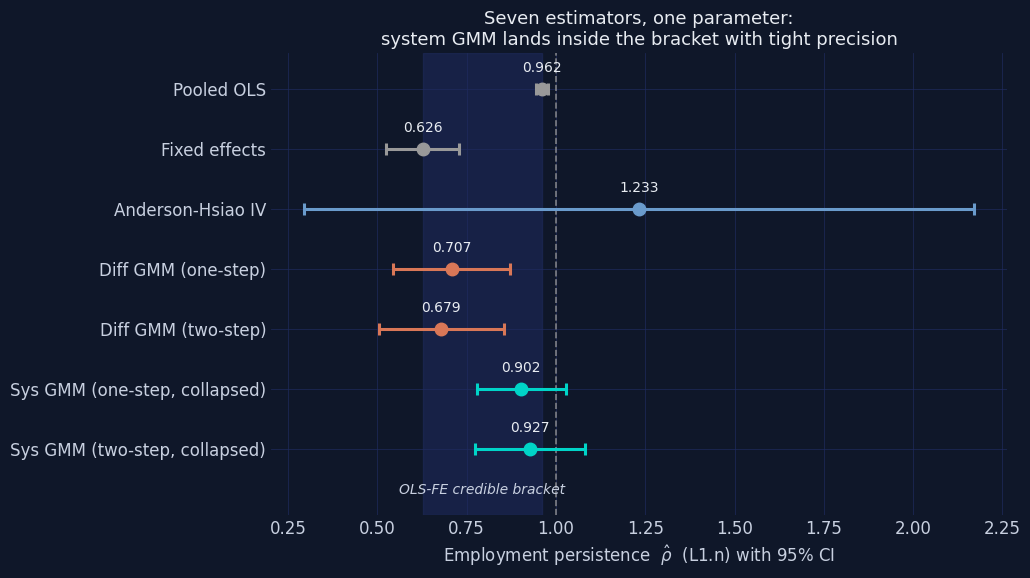

In [17]:
order = ["Pooled OLS", "Fixed effects", "Anderson-Hsiao IV",
         "Diff GMM (one-step)", "Diff GMM (two-step)",
         "Sys GMM (one-step, collapsed)", "Sys GMM (two-step, collapsed)"]
colors = {"Pooled OLS": GRAY, "Fixed effects": GRAY,
          "Anderson-Hsiao IV": STEEL_BLUE,
          "Diff GMM (one-step)": WARM_ORANGE,
          "Diff GMM (two-step)": WARM_ORANGE,
          "Sys GMM (one-step, collapsed)": TEAL,
          "Sys GMM (two-step, collapsed)": TEAL}
plot_df = summary.set_index("estimator").loc[order].reset_index()

fig, ax = plt.subplots(figsize=(9.5, 6))
fig.patch.set_linewidth(0)
ax.axvspan(rho_fe, rho_ols, color=GRID_LINE, alpha=0.55, zorder=0)
ax.text((rho_fe + rho_ols) / 2, -0.75, "OLS-FE credible bracket",
        color=LIGHT_TEXT, fontsize=10, ha="center", style="italic")
ax.axvline(1.0, color=GRAY, lw=1.2, ls="--", alpha=0.8)
ypos = np.arange(len(plot_df))[::-1]
for y, (_, r) in zip(ypos, plot_df.iterrows()):
    ax.errorbar(r["rho1"], y, xerr=1.96 * r["se"], fmt="o",
                color=colors[r["estimator"]], ms=9, capsize=4, lw=2.2,
                capthick=2.2, zorder=3)
    ax.text(r["rho1"], y + 0.28, f"{r['rho1']:.3f}", color=WHITE_TEXT,
            fontsize=10, ha="center")
ax.set_yticks(ypos)
ax.set_yticklabels(plot_df["estimator"])
ax.set_xlabel(r"Employment persistence  $\hat{\rho}$  (L1.n) with 95% CI")
ax.set_ylim(-1.1, len(plot_df) - 0.4)
ax.set_title("Seven estimators, one parameter:\n"
             "system GMM lands inside the bracket with tight precision",
             fontsize=13)
plt.show()

**Interpretation.** The forest plot is the tutorial in one image. The grey markers (OLS at 0.962, FE at 0.626) define the shaded credible band. Anderson-Hsiao's enormous blue whisker straddles everything, including the dashed unit-root line. The orange difference-GMM pair sits at the bottom of the band, hugging the FE bound exactly as Bond's diagnostic predicts under weak instruments. And the teal system-GMM pair (0.902 and 0.927) lands in the upper half of the band with usable precision. Notice what separates the winner from the losers: *nothing on any single printed line of output*. Only the bracket logic, the weak-instrument reasoning, the proliferation experiment, and the replication check — the workflow, not a p-value — identify 0.927 as the defensible answer.

## Summary and next steps

**Key takeaways:**

1. **The bracket.** OLS (0.962) and FE (0.626) bracket the truth from above and below; their disagreement of 0.336 is not noise but a diagnostic measuring stick.
2. **Consistency is not enough.** Anderson-Hsiao is consistent but imprecise (SE 0.48), and difference GMM (0.679, 91 instruments) passed every printed test while hugging the biased FE bound — the textbook weak-instrument symptom when the series is persistent.
3. **System GMM delivers the defensible answer.** $\hat{\rho} = 0.927$ (SE 0.079), inside the bracket, with AR(2) p = 0.994, Hansen p = 0.462, and 32 collapsed instruments against 140 firms.
4. **Read the diagnostics correctly.** AR(1) must reject (mechanical); AR(2) must not reject (it protects the instruments); Hansen is two-tailed in spirit — p drifting toward 1 as instruments pile up is overfitting, not validity.
5. **Verify the toolchain.** The replication of the `pydynpd` published benchmark was exact to all printed digits (L1.n = 0.2710675, 42 instruments), NumPy-2 shim included.

Substantively: about 93 percent of an employment shock survives into the next year — a shock half-life of roughly nine years — though the headline CI [0.773, 1.081] includes the unit root, so the defensible claim is the point estimate and its lower bound.

For the full discussion (practitioner checklist, limitations, exercises, and references), see the blog post: [Dynamic Panel Data Models in Python: From Nickell Bias to System GMM](https://carlos-mendez.org/post/python_dynamic_panel/).

**References (selection):** Arellano & Bond (1991, *REStud*); Anderson & Hsiao (1981, *JASA*); Nickell (1981, *Econometrica*); Blundell & Bond (1998, *J. Econometrics*); Bond (2002, *Portuguese Economic Journal*); Windmeijer (2005, *J. Econometrics*); Roodman (2009, *Stata Journal*); Wu, Hua & Xu (2023, *JOSS* — `pydynpd`).